d_k = 8   |   scale = 1/√8 = 0.3536
Raw score variance  : 1514.4889
Scaled score variance: 189.3111

Output shape    : (5, 8)
Attn row sums   : [1. 1. 1. 1. 1.]


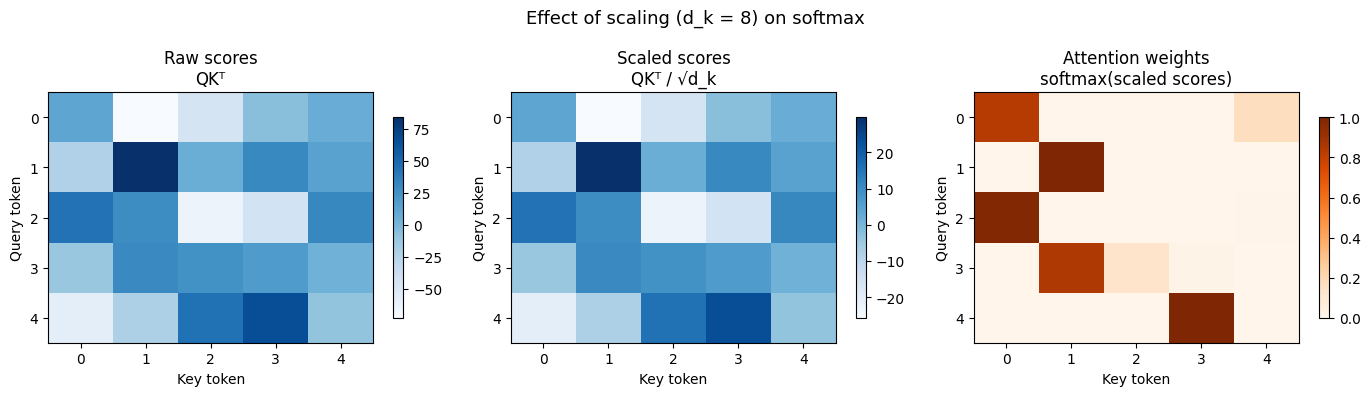

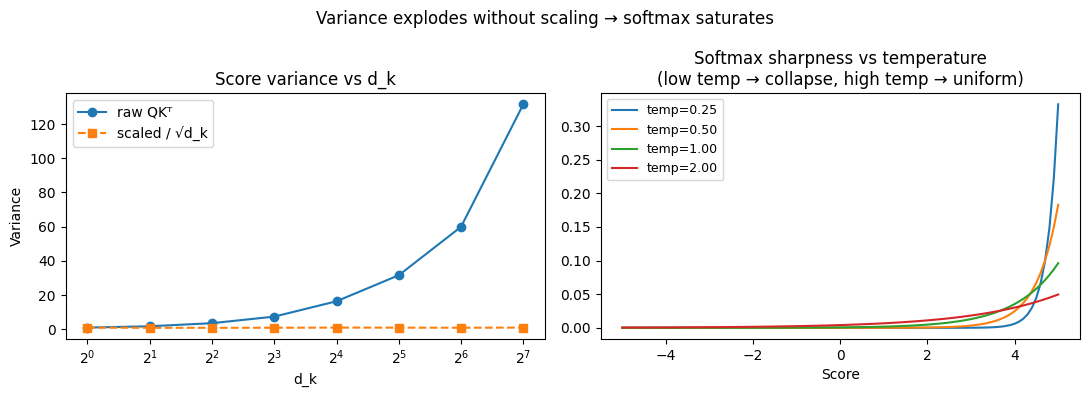

In [1]:
# ============================================================
# Scaled Dot-Product Self-Attention — step-by-step
# Run each cell top to bottom in Google Colab
# ============================================================

# ── Cell 1: imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Cell 2: helpers ─────────────────────────────────────────
def softmax(x):
    """Numerically stable row-wise softmax."""
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None, verbose=True):
    """
    Q, K, V : (seq_len, d_k)
    mask    : (seq_len, seq_len) bool — True means *block* that position
    Returns output (seq_len, d_k) and attention weights (seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    scale = 1.0 / np.sqrt(d_k)          # ← THE SCALING STEP

    # Raw dot-product scores
    scores_raw = Q @ K.T                 # (seq, seq)

    # Scale to control variance
    scores_scaled = scores_raw * scale   # (seq, seq)

    if verbose:
        print(f"d_k = {d_k}   |   scale = 1/√{d_k} = {scale:.4f}")
        print(f"Raw score variance  : {scores_raw.var():.4f}")
        print(f"Scaled score variance: {scores_scaled.var():.4f}\n")

    # Optional causal mask (for decoders)
    if mask is not None:
        scores_scaled = np.where(mask, -1e9, scores_scaled)

    weights = softmax(scores_scaled)     # (seq, seq)
    output  = weights @ V                # (seq, d_k)
    return output, weights

# ── Cell 3: run a demo ───────────────────────────────────────
np.random.seed(0)
SEQ_LEN = 5
D_MODEL  = 16
D_K      = 8    # try changing this to 2, 4, 16, 64

X   = np.random.randn(SEQ_LEN, D_MODEL)
W_q = np.random.randn(D_MODEL, D_K)
W_k = np.random.randn(D_MODEL, D_K)
W_v = np.random.randn(D_MODEL, D_K)

Q = X @ W_q
K = X @ W_k
V = X @ W_v

output, attn = scaled_dot_product_attention(Q, K, V)
print("Output shape    :", output.shape)
print("Attn row sums   :", attn.sum(axis=-1).round(4))   # should all be 1.0

# ── Cell 4: visualise the effect of scaling ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Effect of scaling (d_k = 8) on softmax", fontsize=13)

raw_scores = Q @ K.T
scaled_scores = raw_scores / np.sqrt(D_K)

for ax, (mat, title) in zip(axes[:2], [
    (raw_scores,    "Raw scores\nQKᵀ"),
    (scaled_scores, "Scaled scores\nQKᵀ / √d_k"),
]):
    im = ax.imshow(mat, cmap="Blues", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Key token")
    ax.set_ylabel("Query token")
    plt.colorbar(im, ax=ax, shrink=0.8)

axes[2].imshow(attn, cmap="Oranges", aspect="auto", vmin=0, vmax=1)
axes[2].set_title("Attention weights\nsoftmax(scaled scores)")
axes[2].set_xlabel("Key token")
axes[2].set_ylabel("Query token")
plt.colorbar(plt.cm.ScalarMappable(cmap="Oranges",
             norm=plt.Normalize(0,1)), ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

# ── Cell 5: why scaling matters — variance comparison ────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Variance explodes without scaling → softmax saturates", fontsize=12)

dk_values = [1, 2, 4, 8, 16, 32, 64, 128]
raw_vars, scaled_vars = [], []

for dk in dk_values:
    q = np.random.randn(100, dk)
    k = np.random.randn(100, dk)
    raw = q @ k.T
    raw_vars.append(raw.var())
    scaled_vars.append((raw / np.sqrt(dk)).var())

axes[0].plot(dk_values, raw_vars,    'o-', label='raw QKᵀ')
axes[0].plot(dk_values, scaled_vars, 's--', label='scaled / √d_k')
axes[0].set_xlabel("d_k")
axes[0].set_ylabel("Variance")
axes[0].set_title("Score variance vs d_k")
axes[0].legend()
axes[0].set_xscale('log', base=2)

# Softmax sharpness for different scales
x = np.linspace(-5, 5, 100)
for temp in [0.25, 0.5, 1.0, 2.0]:
    soft = np.exp(x/temp) / np.exp(x/temp).sum()
    axes[1].plot(x, soft, label=f"temp={temp:.2f}")
axes[1].set_title("Softmax sharpness vs temperature\n(low temp → collapse, high temp → uniform)")
axes[1].set_xlabel("Score")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()